In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("WARNING: GPU is not available")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8


In [2]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

DATA_DIR = Path("/content/drive/MyDrive/PathoScope/data")

print("Data directory:", DATA_DIR)
print("Exists:", DATA_DIR.exists())

required_files = [
    "tiles.csv",
    "tiles_img.zip",
    "tiles_norm.zip",
    "ref_stain.npz",
]

print("\nChecking Notebook 01 + 02 outputs:\n")

for name in required_files:
    path = DATA_DIR / name

    if path.exists():
        size_mb = path.stat().st_size / (1024 ** 2)
        print(f"✓ {name:20s} {size_mb:.2f} MB")
    else:
        print(f"✗ {name:20s} MISSING")

Mounted at /content/drive
Data directory: /content/drive/MyDrive/PathoScope/data
Exists: True

Checking Notebook 01 + 02 outputs:

✓ tiles.csv            2.85 MB
✓ tiles_img.zip        339.33 MB
✓ tiles_norm.zip       411.67 MB
✓ ref_stain.npz        0.00 MB


In [3]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("/content/drive/MyDrive/PathoScope/data")

TILES_CSV = DATA_DIR / "tiles.csv"

df = pd.read_csv(TILES_CSV)

print("Data shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nTile label distribution:")
print(df["tile_label"].value_counts(dropna=False).sort_index())

print("\nISUP grade distribution:")
print(df["isup_grade"].value_counts().sort_index())

print("\nData providers:")
print(df["data_provider"].value_counts())

print("\nMissing values:")
print(df.isna().sum())

Data shape: (12800, 13)

Columns:
['tile_id', 'image_id', 'data_provider', 'x', 'y', 'tile_size', 'tissue_fraction', 'tile_label', 'isup_grade', 'gleason_score', 'mask_available', 'image_path', 'mask_path']

Tile label distribution:
tile_label
-1     838
 0    8569
 1    3393
Name: count, dtype: int64

ISUP grade distribution:
isup_grade
0    3520
1    3200
2    1600
3    1472
4    1536
5    1472
Name: count, dtype: int64

Data providers:
data_provider
radboud       6400
karolinska    6400
Name: count, dtype: int64

Missing values:
tile_id            0
image_id           0
data_provider      0
x                  0
y                  0
tile_size          0
tissue_fraction    0
tile_label         0
isup_grade         0
gleason_score      0
mask_available     0
image_path         0
mask_path          0
dtype: int64


In [4]:
import timm
import sklearn
import matplotlib
import numpy as np
import pandas as pd
import torch

print("timm:", timm.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("PyTorch:", torch.__version__)

timm: 1.0.29
scikit-learn: 1.6.1
matplotlib: 3.10.0
NumPy: 2.1.3
Pandas: 2.2.3
PyTorch: 2.11.0+cu128


In [5]:
from pathlib import Path

DATA_DIR = Path("/content/drive/MyDrive/PathoScope/data")
WORK_DIR = Path("/content/pathoscope_03")

WORK_DIR.mkdir(parents=True, exist_ok=True)

TILES_CSV = DATA_DIR / "tiles.csv"
TILES_NORM_ZIP = DATA_DIR / "tiles_norm.zip"

NORM_DIR = WORK_DIR / "tiles_norm"
NORM_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
NUM_CLASSES = 2
BATCH_SIZE = 32
NUM_WORKERS = 2

MODEL_NAME = "efficientnet_b0"

print("Data directory:", DATA_DIR)
print("Normalized tiles ZIP:", TILES_NORM_ZIP)
print("Normalized tiles directory:", NORM_DIR)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Model:", MODEL_NAME)
print("Number of classes:", NUM_CLASSES)

Data directory: /content/drive/MyDrive/PathoScope/data
Normalized tiles ZIP: /content/drive/MyDrive/PathoScope/data/tiles_norm.zip
Normalized tiles directory: /content/pathoscope_03/tiles_norm
Image size: 224
Batch size: 32
Model: efficientnet_b0
Number of classes: 2


In [6]:
import zipfile

if any(NORM_DIR.iterdir()):
    print("Normalized tiles directory is already populated.")
    print("Files found:", len(list(NORM_DIR.glob("*.jpg"))))
else:
    print("Extracting normalized tiles...")

    with zipfile.ZipFile(TILES_NORM_ZIP, "r") as z:
        z.extractall(NORM_DIR)

    print("Extraction complete.")

print("Normalized tile files:", len(list(NORM_DIR.glob("*.jpg"))))

Extracting normalized tiles...
Extraction complete.
Normalized tile files: 12800


In [7]:
import os

df["norm_path"] = df["tile_id"].apply(
    lambda x: NORM_DIR / x
)

df["norm_exists"] = df["norm_path"].apply(
    lambda x: x.exists()
)

print("Total CSV rows:", len(df))
print("Normalized images found:", df["norm_exists"].sum())
print("Missing normalized images:", (~df["norm_exists"]).sum())

print("\nLabel distribution:")
print(df["tile_label"].value_counts().sort_index())

if (~df["norm_exists"]).sum() == 0:
    print("\n✓ Every CSV record has a normalized image.")
else:
    print("\n⚠ Some normalized images are missing.")

print("\nExample:")
print(df[["tile_id", "tile_label", "isup_grade", "norm_path"]].head(3))

Total CSV rows: 12800
Normalized images found: 0
Missing normalized images: 12800

Label distribution:
tile_label
-1     838
 0    8569
 1    3393
Name: count, dtype: int64

⚠ Some normalized images are missing.

Example:
                                        tile_id  tile_label  isup_grade  \
0  8f264374ed3fa427615c1650218e7f21_x1536_y1536           0           1   
1  8f264374ed3fa427615c1650218e7f21_x1792_y4864           1           1   
2  8f264374ed3fa427615c1650218e7f21_x2560_y7936           0           1   

                                           norm_path  
0  /content/pathoscope_03/tiles_norm/8f264374ed3f...  
1  /content/pathoscope_03/tiles_norm/8f264374ed3f...  
2  /content/pathoscope_03/tiles_norm/8f264374ed3f...  


In [8]:
df["norm_path"] = df["tile_id"].apply(
    lambda x: NORM_DIR / f"{x}.jpg"
)

df["norm_exists"] = df["norm_path"].apply(
    lambda x: x.exists()
)

print("Total CSV rows:", len(df))
print("Normalized images found:", df["norm_exists"].sum())
print("Missing normalized images:", (~df["norm_exists"]).sum())

if (~df["norm_exists"]).sum() == 0:
    print("\n✓ All 12,800 tile records are correctly linked to normalized images.")
else:
    print("\n⚠ Some normalized images are still missing.")

print("\nExample:")
print(df[["tile_id", "tile_label", "isup_grade", "norm_path"]].head(3))

Total CSV rows: 12800
Normalized images found: 12800
Missing normalized images: 0

✓ All 12,800 tile records are correctly linked to normalized images.

Example:
                                        tile_id  tile_label  isup_grade  \
0  8f264374ed3fa427615c1650218e7f21_x1536_y1536           0           1   
1  8f264374ed3fa427615c1650218e7f21_x1792_y4864           1           1   
2  8f264374ed3fa427615c1650218e7f21_x2560_y7936           0           1   

                                           norm_path  
0  /content/pathoscope_03/tiles_norm/8f264374ed3f...  
1  /content/pathoscope_03/tiles_norm/8f264374ed3f...  
2  /content/pathoscope_03/tiles_norm/8f264374ed3f...  


In [9]:
unknown_df = df[df["tile_label"] == -1].copy()

print("Tiles with label -1:", len(unknown_df))

print("\nISUP grades for tile_label = -1:")
print(unknown_df["isup_grade"].value_counts().sort_index())

print("\nData providers:")
print(unknown_df["data_provider"].value_counts())

print("\nMask availability:")
print(unknown_df["mask_available"].value_counts())

print("\nTissue fraction:")
print(unknown_df["tissue_fraction"].describe())

print("\nSample records:")
print(
    unknown_df[
        [
            "tile_id",
            "image_id",
            "tile_label",
            "isup_grade",
            "gleason_score",
            "mask_available",
            "tissue_fraction",
        ]
    ].head(10)
)


Tiles with label -1: 838

ISUP grades for tile_label = -1:
isup_grade
0     15
1    437
2    136
3    111
4    117
5     22
Name: count, dtype: int64

Data providers:
data_provider
karolinska    713
radboud       125
Name: count, dtype: int64

Mask availability:
mask_available
1    838
Name: count, dtype: int64

Tissue fraction:
count    838.000000
mean       0.968144
std        0.134937
min        0.000000
25%        0.984375
50%        0.996094
75%        1.000000
max        1.000000
Name: tissue_fraction, dtype: float64

Sample records:
                                            tile_id  \
157  871f73f44e29b8f3da8048aaf387a673_x24832_y18688   
158  871f73f44e29b8f3da8048aaf387a673_x24576_y18944   
159  871f73f44e29b8f3da8048aaf387a673_x24832_y18944   
160  871f73f44e29b8f3da8048aaf387a673_x24832_y19200   
161  871f73f44e29b8f3da8048aaf387a673_x24576_y19968   
181  871f73f44e29b8f3da8048aaf387a673_x24832_y19456   
182  871f73f44e29b8f3da8048aaf387a673_x24576_y19712   
326    3f5ace0

In [10]:
from PIL import Image
import numpy as np

sample_unknown = unknown_df.head(10)

print("Checking masks for 10 tile_label = -1 tiles:\n")

for _, row in sample_unknown.iterrows():
    mask_path = DATA_DIR / "tiles_mask.zip"

    tile_id = row["tile_id"]
    extracted_mask = Path("/content/pathoscope_03") / "masks" / f"{tile_id}.png"

    print(tile_id)
    print("  ISUP:", row["isup_grade"])
    print("  Gleason:", row["gleason_score"])
    print("  Expected mask path:", extracted_mask)
    print("  Exists:", extracted_mask.exists())
    print()


Checking masks for 10 tile_label = -1 tiles:

871f73f44e29b8f3da8048aaf387a673_x24832_y18688
  ISUP: 1
  Gleason: 3+3
  Expected mask path: /content/pathoscope_03/masks/871f73f44e29b8f3da8048aaf387a673_x24832_y18688.png
  Exists: False

871f73f44e29b8f3da8048aaf387a673_x24576_y18944
  ISUP: 1
  Gleason: 3+3
  Expected mask path: /content/pathoscope_03/masks/871f73f44e29b8f3da8048aaf387a673_x24576_y18944.png
  Exists: False

871f73f44e29b8f3da8048aaf387a673_x24832_y18944
  ISUP: 1
  Gleason: 3+3
  Expected mask path: /content/pathoscope_03/masks/871f73f44e29b8f3da8048aaf387a673_x24832_y18944.png
  Exists: False

871f73f44e29b8f3da8048aaf387a673_x24832_y19200
  ISUP: 1
  Gleason: 3+3
  Expected mask path: /content/pathoscope_03/masks/871f73f44e29b8f3da8048aaf387a673_x24832_y19200.png
  Exists: False

871f73f44e29b8f3da8048aaf387a673_x24576_y19968
  ISUP: 1
  Gleason: 3+3
  Expected mask path: /content/pathoscope_03/masks/871f73f44e29b8f3da8048aaf387a673_x24576_y19968.png
  Exists: False


In [11]:
MASK_ZIP = DATA_DIR / "tiles_mask.zip"
MASK_DIR = WORK_DIR / "masks"

MASK_DIR.mkdir(parents=True, exist_ok=True)

import zipfile

if any(MASK_DIR.iterdir()):
    print("Mask directory is already populated.")
    print("Files found:", len(list(MASK_DIR.glob("*.png"))))
else:
    print("Extracting masks...")

    with zipfile.ZipFile(MASK_ZIP, "r") as z:
        z.extractall(MASK_DIR)

    print("Extraction complete.")

print("Mask files:", len(list(MASK_DIR.glob("*.png"))))

Extracting masks...
Extraction complete.
Mask files: 12800


In [12]:
from PIL import Image
import numpy as np

print("Inspecting masks for tile_label = -1:\n")

for _, row in unknown_df.head(10).iterrows():
    tile_id = row["tile_id"]
    mask_path = MASK_DIR / f"{tile_id}.png"

    mask = np.array(Image.open(mask_path))

    unique_values, counts = np.unique(mask, return_counts=True)

    print(f"Tile: {tile_id}")
    print(f"  Mask shape: {mask.shape}")
    print(f"  Mask dtype: {mask.dtype}")
    print(f"  Unique values: {unique_values}")
    print(f"  Pixel counts: {counts}")
    print(f"  Max value: {mask.max()}")
    print()

Inspecting masks for tile_label = -1:

Tile: 871f73f44e29b8f3da8048aaf387a673_x24832_y18688
  Mask shape: (256, 256)
  Mask dtype: uint8
  Unique values: [0]
  Pixel counts: [65536]
  Max value: 0

Tile: 871f73f44e29b8f3da8048aaf387a673_x24576_y18944
  Mask shape: (256, 256)
  Mask dtype: uint8
  Unique values: [0]
  Pixel counts: [65536]
  Max value: 0

Tile: 871f73f44e29b8f3da8048aaf387a673_x24832_y18944
  Mask shape: (256, 256)
  Mask dtype: uint8
  Unique values: [0]
  Pixel counts: [65536]
  Max value: 0

Tile: 871f73f44e29b8f3da8048aaf387a673_x24832_y19200
  Mask shape: (256, 256)
  Mask dtype: uint8
  Unique values: [0]
  Pixel counts: [65536]
  Max value: 0

Tile: 871f73f44e29b8f3da8048aaf387a673_x24576_y19968
  Mask shape: (256, 256)
  Mask dtype: uint8
  Unique values: [0]
  Pixel counts: [65536]
  Max value: 0

Tile: 871f73f44e29b8f3da8048aaf387a673_x24832_y19456
  Mask shape: (256, 256)
  Mask dtype: uint8
  Unique values: [0]
  Pixel counts: [65536]
  Max value: 0

Tile: 8

In [13]:
from PIL import Image
import numpy as np

mask_stats = []

for label in [-1, 0, 1]:
    subset = df[df["tile_label"] == label]

    nonzero_fractions = []

    for _, row in subset.iterrows():
        mask_path = MASK_DIR / f"{row['tile_id']}.png"
        mask = np.array(Image.open(mask_path))

        nonzero_fraction = np.count_nonzero(mask) / mask.size
        nonzero_fractions.append(nonzero_fraction)

    mask_stats.append({
        "tile_label": label,
        "tiles": len(subset),
        "mean_mask_fraction": np.mean(nonzero_fractions),
        "median_mask_fraction": np.median(nonzero_fractions),
        "tiles_with_mask_pixels": np.sum(np.array(nonzero_fractions) > 0),
        "tiles_without_mask_pixels": np.sum(np.array(nonzero_fractions) == 0),
    })

mask_stats_df = pd.DataFrame(mask_stats)

print(mask_stats_df.to_string(index=False))

 tile_label  tiles  mean_mask_fraction  median_mask_fraction  tiles_with_mask_pixels  tiles_without_mask_pixels
         -1    838            0.000000                   0.0                       0                        838
          0   8569            0.984481                   1.0                    8569                          0
          1   3393            0.981146                   1.0                    3393                          0


In [14]:
print("Tile-label distribution by ISUP grade:\n")

label_by_isup = pd.crosstab(
    df["isup_grade"],
    df["tile_label"]
)

print(label_by_isup)

print("\nRow percentages:\n")

label_by_isup_pct = pd.crosstab(
    df["isup_grade"],
    df["tile_label"],
    normalize="index"
) * 100

print(label_by_isup_pct.round(2))

Tile-label distribution by ISUP grade:

tile_label   -1     0    1
isup_grade                
0            15  3505    0
1           437  2089  674
2           136   877  587
3           111   657  704
4           117   715  704
5            22   726  724

Row percentages:

tile_label     -1      0      1
isup_grade                     
0            0.43  99.57   0.00
1           13.66  65.28  21.06
2            8.50  54.81  36.69
3            7.54  44.63  47.83
4            7.62  46.55  45.83
5            1.49  49.32  49.18


In [15]:
clf_df = df[df["tile_label"].isin([0, 1])].copy()

clf_df["label"] = clf_df["tile_label"].astype(int)

print("Original tiles:", len(df))
print("Classification tiles:", len(clf_df))
print("Excluded tile_label = -1:", (df["tile_label"] == -1).sum())

print("\nClassification label distribution:")
print(clf_df["label"].value_counts().sort_index())

print("\nClassification label percentages:")
print(
    (clf_df["label"].value_counts(normalize=True).sort_index() * 100).round(2)
)

print("\nMissing image paths:")
print((~clf_df["norm_exists"]).sum())

Original tiles: 12800
Classification tiles: 11962
Excluded tile_label = -1: 838

Classification label distribution:
label
0    8569
1    3393
Name: count, dtype: int64

Classification label percentages:
label
0    71.64
1    28.36
Name: proportion, dtype: float64

Missing image paths:
0


In [16]:
from sklearn.model_selection import train_test_split

slide_labels = (
    clf_df.groupby("image_id")["label"]
    .agg(lambda x: int(x.mean() >= 0.5))
    .reset_index()
)

print("Total slides:", len(slide_labels))

train_slides, temp_slides = train_test_split(
    slide_labels,
    test_size=0.30,
    random_state=42,
    stratify=slide_labels["label"]
)

val_slides, test_slides = train_test_split(
    temp_slides,
    test_size=0.50,
    random_state=42,
    stratify=temp_slides["label"]
)

train_ids = set(train_slides["image_id"])
val_ids = set(val_slides["image_id"])
test_ids = set(test_slides["image_id"])

train_df = clf_df[clf_df["image_id"].isin(train_ids)].copy()
val_df = clf_df[clf_df["image_id"].isin(val_ids)].copy()
test_df = clf_df[clf_df["image_id"].isin(test_ids)].copy()

print("\nSlide split:")
print("Train slides:", len(train_ids))
print("Validation slides:", len(val_ids))
print("Test slides:", len(test_ids))

print("\nTile split:")
print("Train tiles:", len(train_df))
print("Validation tiles:", len(val_df))
print("Test tiles:", len(test_df))

print("\nTrain labels:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation labels:")
print(val_df["label"].value_counts().sort_index())

print("\nTest labels:")
print(test_df["label"].value_counts().sort_index())

print("\nLeakage check:")
print("Train ∩ Val:", len(train_ids & val_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Val ∩ Test:", len(val_ids & test_ids))

Total slides: 200

Slide split:
Train slides: 140
Validation slides: 30
Test slides: 30

Tile split:
Train tiles: 8464
Validation tiles: 1800
Test tiles: 1698

Train labels:
label
0    6088
1    2376
Name: count, dtype: int64

Validation labels:
label
0    1268
1     532
Name: count, dtype: int64

Test labels:
label
0    1213
1     485
Name: count, dtype: int64

Leakage check:
Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


In [17]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])


class PathoScopeTileDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image = Image.open(row["norm_path"]).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = PathoScopeTileDataset(
    train_df,
    transform=train_transform
)

val_dataset = PathoScopeTileDataset(
    val_df,
    transform=eval_transform
)

test_dataset = PathoScopeTileDataset(
    test_df,
    transform=eval_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 8464
Validation dataset: 1800
Test dataset: 1698


In [18]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 265
Validation batches: 57
Test batches: 54


In [19]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Image dtype:", images.dtype)
print("Label shape:", labels.shape)
print("Labels:", labels[:20].tolist())

print("\nImage value range:")
print("Min:", images.min().item())
print("Max:", images.max().item())

print("\nUnique labels in batch:")
print(torch.unique(labels).tolist())

Image batch shape: torch.Size([32, 3, 224, 224])
Image dtype: torch.float32
Label shape: torch.Size([32])
Labels: [0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Image value range:
Min: -2.1179039478302
Max: 2.640000104904175

Unique labels in batch:
[0, 1]


In [20]:
import timm
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(device)

print("Device:", device)
print("Model:", MODEL_NAME)
print("Number of output classes:", NUM_CLASSES)

print("\nFinal classifier:")
print(model.classifier)

print("\nTotal parameters:", sum(p.numel() for p in model.parameters()))
print(
    "Trainable parameters:",
    sum(p.numel() for p in model.parameters() if p.requires_grad)
)

model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Device: cuda
Model: efficientnet_b0
Number of output classes: 2

Final classifier:
Linear(in_features=1280, out_features=2, bias=True)

Total parameters: 4010110
Trainable parameters: 4010110


In [21]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"].values
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

print("Training class counts:")
print(train_df["label"].value_counts().sort_index())

print("\nClass weights:")
print(class_weights)

print("\nClass 0 weight:", class_weights[0].item())
print("Class 1 weight:", class_weights[1].item())

Training class counts:
label
0    6088
1    2376
Name: count, dtype: int64

Class weights:
tensor([0.6951, 1.7811], device='cuda:0')

Class 0 weight: 0.6951379776000977
Class 1 weight: 1.7811447381973267


In [22]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Loss function:")
print(criterion)

print("\nOptimizer:")
print(optimizer)

print("\nLearning rate:", optimizer.param_groups[0]["lr"])
print("Weight decay:", optimizer.param_groups[0]["weight_decay"])

Loss function:
CrossEntropyLoss()

Optimizer:
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)

Learning rate: 0.0001
Weight decay: 0.0001


In [23]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
import numpy as np

def evaluate_model(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_probs = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probabilities = torch.softmax(outputs, dim=1)
            predictions = torch.argmax(outputs, dim=1)

            total_loss += loss.item() * images.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probabilities[:, 1].cpu().numpy())
            all_preds.extend(predictions.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)

    auc = roc_auc_score(all_labels, all_probs)
    f1 = f1_score(all_labels, all_preds)
    accuracy = accuracy_score(all_labels, all_preds)

    return avg_loss, auc, f1, accuracy


print("Evaluation function created successfully.")

Evaluation function created successfully.


In [24]:
import copy
import time

NUM_EPOCHS = 5

best_val_auc = -np.inf
best_model_state = None
history = []

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    model.train()

    running_loss = 0.0
    train_labels = []
    train_probs = []
    train_preds = []

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(outputs, dim=1)

        running_loss += loss.item() * images.size(0)

        train_labels.extend(labels.detach().cpu().numpy())
        train_probs.extend(probabilities[:, 1].detach().cpu().numpy())
        train_preds.extend(predictions.detach().cpu().numpy())

    train_loss = running_loss / len(train_loader.dataset)
    train_auc = roc_auc_score(train_labels, train_probs)
    train_f1 = f1_score(train_labels, train_preds)
    train_accuracy = accuracy_score(train_labels, train_preds)

    val_loss, val_auc, val_f1, val_accuracy = evaluate_model(
        model,
        val_loader,
        criterion,
        device
    )

    epoch_time = time.time() - start_time

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_auc": train_auc,
        "train_f1": train_f1,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_auc": val_auc,
        "val_f1": val_f1,
        "val_accuracy": val_accuracy,
        "time_seconds": epoch_time
    })

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_model_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train AUC: {train_auc:.4f} | "
        f"Train F1: {train_f1:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val AUC: {val_auc:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

model.load_state_dict(best_model_state)

print("\nTraining complete.")
print(f"Best validation AUC: {best_val_auc:.4f}")

Epoch 1/5 | Train Loss: 1.1103 | Train AUC: 0.8066 | Train F1: 0.6085 | Train Acc: 0.7359 | Val Loss: 0.8473 | Val AUC: 0.8368 | Val F1: 0.6605 | Val Acc: 0.7750 | Time: 51.9s
Epoch 2/5 | Train Loss: 0.6421 | Train AUC: 0.8688 | Train F1: 0.6738 | Train Acc: 0.7865 | Val Loss: 0.6402 | Val AUC: 0.8451 | Val F1: 0.6760 | Val Acc: 0.7822 | Time: 51.1s
Epoch 3/5 | Train Loss: 0.4713 | Train AUC: 0.9025 | Train F1: 0.7289 | Train Acc: 0.8266 | Val Loss: 0.5483 | Val AUC: 0.8739 | Val F1: 0.7126 | Val Acc: 0.8217 | Time: 51.3s
Epoch 4/5 | Train Loss: 0.4228 | Train AUC: 0.9197 | Train F1: 0.7570 | Train Acc: 0.8456 | Val Loss: 0.6352 | Val AUC: 0.8537 | Val F1: 0.6912 | Val Acc: 0.7994 | Time: 51.6s
Epoch 5/5 | Train Loss: 0.3772 | Train AUC: 0.9277 | Train F1: 0.7566 | Train Acc: 0.8471 | Val Loss: 0.5916 | Val AUC: 0.8884 | Val F1: 0.7205 | Val Acc: 0.8156 | Time: 51.5s

Training complete.
Best validation AUC: 0.8884


In [25]:
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

test_loss, test_auc, test_f1, test_accuracy = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

model.eval()

all_test_labels = []
all_test_probs = []
all_test_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(outputs, dim=1)

        all_test_labels.extend(labels.numpy())
        all_test_probs.extend(probabilities[:, 1].cpu().numpy())
        all_test_preds.extend(predictions.cpu().numpy())

test_cm = confusion_matrix(
    all_test_labels,
    all_test_preds,
    labels=[0, 1]
)

print("Final test results")
print("------------------")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test AUC:      {test_auc:.4f}")
print(f"Test F1:       {test_f1:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

print("\nConfusion Matrix:")
print(test_cm)

print("\nClassification Report:")
print(
    classification_report(
        all_test_labels,
        all_test_preds,
        labels=[0, 1],
        target_names=["Class 0", "Class 1"],
        digits=4
    )
)

Final test results
------------------
Test Loss:     0.9616
Test AUC:      0.7630
Test F1:       0.6070
Test Accuracy: 0.7544

Confusion Matrix:
[[959 254]
 [163 322]]

Classification Report:
              precision    recall  f1-score   support

     Class 0     0.8547    0.7906    0.8214      1213
     Class 1     0.5590    0.6639    0.6070       485

    accuracy                         0.7544      1698
   macro avg     0.7069    0.7273    0.7142      1698
weighted avg     0.7703    0.7544    0.7602      1698



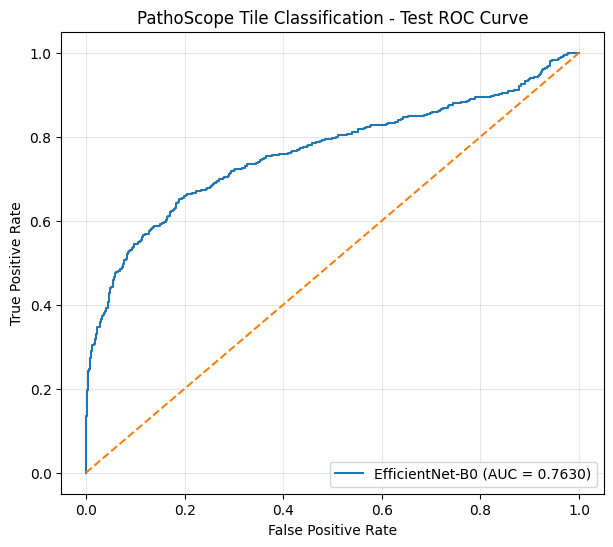

ROC AUC: 0.7630


In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(
    all_test_labels,
    all_test_probs
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"EfficientNet-B0 (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("PathoScope Tile Classification - Test ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")

In [27]:
MODEL_OUTPUT = WORK_DIR / "tile_clf.pth"

checkpoint = {
    "model_name": MODEL_NAME,
    "num_classes": NUM_CLASSES,
    "img_size": IMG_SIZE,
    "state_dict": model.state_dict(),
    "best_val_auc": float(best_val_auc),
    "test_auc": float(test_auc),
    "test_f1": float(test_f1),
    "test_accuracy": float(test_accuracy),
    "class_weights": class_weights.detach().cpu()
}

torch.save(checkpoint, MODEL_OUTPUT)

print("Model saved successfully.")
print("Path:", MODEL_OUTPUT)
print("File size (MB):", round(MODEL_OUTPUT.stat().st_size / (1024 ** 2), 2))

Model saved successfully.
Path: /content/pathoscope_03/tile_clf.pth
File size (MB): 15.58


In [28]:
MODEL_COMPARISON_DIR = WORK_DIR / "model_comparison"
MODEL_COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAMES_TO_TEST = [
    "efficientnet_b0",
    "efficientnet_b1",
    "resnet50",
    "densenet121",
    "convnext_tiny",
]

print("Models to compare:")
for i, name in enumerate(MODEL_NAMES_TO_TEST, 1):
    print(f"{i}. {name}")

print("\nOutput directory:")
print(MODEL_COMPARISON_DIR)

Models to compare:
1. efficientnet_b0
2. efficientnet_b1
3. resnet50
4. densenet121
5. convnext_tiny

Output directory:
/content/pathoscope_03/model_comparison


In [29]:
resnet50 = timm.create_model(
    "resnet50",
    pretrained=True,
    num_classes=2
)

resnet50 = resnet50.to(device)

print("Model: ResNet50")
print("Device:", device)
print("Final classifier:", resnet50.fc)

print(
    "Total parameters:",
    sum(p.numel() for p in resnet50.parameters())
)

print(
    "Trainable parameters:",
    sum(p.numel() for p in resnet50.parameters() if p.requires_grad)
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

Model: ResNet50
Device: cuda
Final classifier: Linear(in_features=2048, out_features=2, bias=True)
Total parameters: 23512130
Trainable parameters: 23512130


In [30]:
resnet_optimizer = torch.optim.AdamW(
    resnet50.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

resnet_criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("ResNet50 loss:", resnet_criterion)
print("ResNet50 optimizer:", resnet_optimizer.__class__.__name__)
print("Learning rate:", resnet_optimizer.param_groups[0]["lr"])
print("Weight decay:", resnet_optimizer.param_groups[0]["weight_decay"])

ResNet50 loss: CrossEntropyLoss()
ResNet50 optimizer: AdamW
Learning rate: 0.0001
Weight decay: 0.0001


In [31]:
NUM_EPOCHS_RESNET = 5

best_resnet_val_auc = -np.inf
best_resnet_state = None
resnet_history = []

for epoch in range(NUM_EPOCHS_RESNET):
    start_time = time.time()

    resnet50.train()

    running_loss = 0.0
    train_labels = []
    train_probs = []
    train_preds = []

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        resnet_optimizer.zero_grad(set_to_none=True)

        outputs = resnet50(images)
        loss = resnet_criterion(outputs, labels)

        loss.backward()
        resnet_optimizer.step()

        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(outputs, dim=1)

        running_loss += loss.item() * images.size(0)

        train_labels.extend(labels.detach().cpu().numpy())
        train_probs.extend(probabilities[:, 1].detach().cpu().numpy())
        train_preds.extend(predictions.detach().cpu().numpy())

    train_loss = running_loss / len(train_loader.dataset)
    train_auc = roc_auc_score(train_labels, train_probs)
    train_f1 = f1_score(train_labels, train_preds)
    train_accuracy = accuracy_score(train_labels, train_preds)

    val_loss, val_auc, val_f1, val_accuracy = evaluate_model(
        resnet50,
        val_loader,
        resnet_criterion,
        device
    )

    epoch_time = time.time() - start_time

    resnet_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_auc": train_auc,
        "train_f1": train_f1,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_auc": val_auc,
        "val_f1": val_f1,
        "val_accuracy": val_accuracy,
        "time_seconds": epoch_time
    })

    if val_auc > best_resnet_val_auc:
        best_resnet_val_auc = val_auc
        best_resnet_state = copy.deepcopy(resnet50.state_dict())

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS_RESNET} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train AUC: {train_auc:.4f} | "
        f"Train F1: {train_f1:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val AUC: {val_auc:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

resnet50.load_state_dict(best_resnet_state)

print("\nResNet50 training complete.")
print(f"Best ResNet50 validation AUC: {best_resnet_val_auc:.4f}")

Epoch 1/5 | Train Loss: 0.5402 | Train AUC: 0.8222 | Train F1: 0.6326 | Train Acc: 0.7632 | Val Loss: 0.4609 | Val AUC: 0.8879 | Val F1: 0.6964 | Val Acc: 0.7844 | Time: 103.8s
Epoch 2/5 | Train Loss: 0.4254 | Train AUC: 0.8865 | Train F1: 0.7047 | Train Acc: 0.8164 | Val Loss: 0.4467 | Val AUC: 0.8961 | Val F1: 0.7201 | Val Acc: 0.8039 | Time: 103.1s
Epoch 3/5 | Train Loss: 0.3880 | Train AUC: 0.9056 | Train F1: 0.7330 | Train Acc: 0.8367 | Val Loss: 0.3962 | Val AUC: 0.9037 | Val F1: 0.7555 | Val Acc: 0.8511 | Time: 102.6s
Epoch 4/5 | Train Loss: 0.3689 | Train AUC: 0.9145 | Train F1: 0.7463 | Train Acc: 0.8470 | Val Loss: 0.3875 | Val AUC: 0.9070 | Val F1: 0.7550 | Val Acc: 0.8500 | Time: 101.9s
Epoch 5/5 | Train Loss: 0.3565 | Train AUC: 0.9205 | Train F1: 0.7609 | Train Acc: 0.8559 | Val Loss: 0.3988 | Val AUC: 0.9081 | Val F1: 0.7610 | Val Acc: 0.8461 | Time: 102.5s

ResNet50 training complete.
Best ResNet50 validation AUC: 0.9081


In [32]:
resnet_test_loss, resnet_test_auc, resnet_test_f1, resnet_test_accuracy = evaluate_model(
    resnet50,
    test_loader,
    resnet_criterion,
    device
)

print("ResNet50 final test results")
print("---------------------------")
print(f"Test Loss:     {resnet_test_loss:.4f}")
print(f"Test AUC:      {resnet_test_auc:.4f}")
print(f"Test F1:       {resnet_test_f1:.4f}")
print(f"Test Accuracy: {resnet_test_accuracy:.4f}")

ResNet50 final test results
---------------------------
Test Loss:     0.5668
Test AUC:      0.7941
Test F1:       0.6614
Test Accuracy: 0.7980


In [33]:
resnet50.eval()

resnet_test_labels = []
resnet_test_probs = []
resnet_test_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)

        outputs = resnet50(images)
        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(outputs, dim=1)

        resnet_test_labels.extend(labels.numpy())
        resnet_test_probs.extend(
            probabilities[:, 1].cpu().numpy()
        )
        resnet_test_preds.extend(
            predictions.cpu().numpy()
        )

resnet_cm = confusion_matrix(
    resnet_test_labels,
    resnet_test_preds,
    labels=[0, 1]
)

print("ResNet50 Confusion Matrix:")
print(resnet_cm)

print("\nResNet50 Classification Report:")
print(
    classification_report(
        resnet_test_labels,
        resnet_test_preds,
        labels=[0, 1],
        target_names=["Class 0", "Class 1"],
        digits=4
    )
)

ResNet50 Confusion Matrix:
[[1020  193]
 [ 150  335]]

ResNet50 Classification Report:
              precision    recall  f1-score   support

     Class 0     0.8718    0.8409    0.8561      1213
     Class 1     0.6345    0.6907    0.6614       485

    accuracy                         0.7980      1698
   macro avg     0.7531    0.7658    0.7587      1698
weighted avg     0.8040    0.7980    0.8005      1698



In [34]:
densenet121 = timm.create_model(
    "densenet121",
    pretrained=True,
    num_classes=2
)

densenet121 = densenet121.to(device)

print("Model: DenseNet121")
print("Device:", device)
print("Final classifier:", densenet121.classifier)

print(
    "Total parameters:",
    sum(p.numel() for p in densenet121.parameters())
)

print(
    "Trainable parameters:",
    sum(p.numel() for p in densenet121.parameters() if p.requires_grad)
)

model.safetensors: reconstructing file:   0%|          |  0.00B / 32.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Model: DenseNet121
Device: cuda
Final classifier: Linear(in_features=1024, out_features=2, bias=True)
Total parameters: 6955906
Trainable parameters: 6955906


In [36]:
densenet_optimizer = torch.optim.AdamW(
    densenet121.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

densenet_criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("DenseNet121 loss:", densenet_criterion)
print("DenseNet121 optimizer:", densenet_optimizer.__class__.__name__)
print("Learning rate:", densenet_optimizer.param_groups[0]["lr"])
print("Weight decay:", densenet_optimizer.param_groups[0]["weight_decay"])

DenseNet121 loss: CrossEntropyLoss()
DenseNet121 optimizer: AdamW
Learning rate: 0.0001
Weight decay: 0.0001


In [37]:
NUM_EPOCHS_DENSENET = 5

best_densenet_val_auc = -np.inf
best_densenet_state = None
densenet_history = []

for epoch in range(NUM_EPOCHS_DENSENET):
    start_time = time.time()

    densenet121.train()

    running_loss = 0.0
    train_labels = []
    train_probs = []
    train_preds = []

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        densenet_optimizer.zero_grad(set_to_none=True)

        outputs = densenet121(images)
        loss = densenet_criterion(outputs, labels)

        loss.backward()
        densenet_optimizer.step()

        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(outputs, dim=1)

        running_loss += loss.item() * images.size(0)

        train_labels.extend(labels.detach().cpu().numpy())
        train_probs.extend(probabilities[:, 1].detach().cpu().numpy())
        train_preds.extend(predictions.detach().cpu().numpy())

    train_loss = running_loss / len(train_loader.dataset)
    train_auc = roc_auc_score(train_labels, train_probs)
    train_f1 = f1_score(train_labels, train_preds)
    train_accuracy = accuracy_score(train_labels, train_preds)

    val_loss, val_auc, val_f1, val_accuracy = evaluate_model(
        densenet121,
        val_loader,
        densenet_criterion,
        device
    )

    epoch_time = time.time() - start_time

    densenet_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_auc": train_auc,
        "train_f1": train_f1,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_auc": val_auc,
        "val_f1": val_f1,
        "val_accuracy": val_accuracy,
        "time_seconds": epoch_time
    })

    if val_auc > best_densenet_val_auc:
        best_densenet_val_auc = val_auc
        best_densenet_state = copy.deepcopy(densenet121.state_dict())

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS_DENSENET} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train AUC: {train_auc:.4f} | "
        f"Train F1: {train_f1:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val AUC: {val_auc:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

densenet121.load_state_dict(best_densenet_state)

print("\nDenseNet121 training complete.")
print(f"Best DenseNet121 validation AUC: {best_densenet_val_auc:.4f}")

Epoch 1/5 | Train Loss: 0.4639 | Train AUC: 0.8625 | Train F1: 0.6745 | Train Acc: 0.7851 | Val Loss: 0.3980 | Val AUC: 0.9014 | Val F1: 0.7567 | Val Acc: 0.8539 | Time: 98.3s
Epoch 2/5 | Train Loss: 0.3903 | Train AUC: 0.9036 | Train F1: 0.7317 | Train Acc: 0.8362 | Val Loss: 0.3761 | Val AUC: 0.9097 | Val F1: 0.7705 | Val Acc: 0.8617 | Time: 97.0s
Epoch 3/5 | Train Loss: 0.3528 | Train AUC: 0.9213 | Train F1: 0.7641 | Train Acc: 0.8579 | Val Loss: 0.3958 | Val AUC: 0.9070 | Val F1: 0.7558 | Val Acc: 0.8428 | Time: 96.9s
Epoch 4/5 | Train Loss: 0.3290 | Train AUC: 0.9325 | Train F1: 0.7713 | Train Acc: 0.8628 | Val Loss: 0.4128 | Val AUC: 0.8983 | Val F1: 0.7350 | Val Acc: 0.8306 | Time: 95.3s
Epoch 5/5 | Train Loss: 0.2994 | Train AUC: 0.9446 | Train F1: 0.8036 | Train Acc: 0.8824 | Val Loss: 0.4275 | Val AUC: 0.8983 | Val F1: 0.7375 | Val Acc: 0.8283 | Time: 95.6s

DenseNet121 training complete.
Best DenseNet121 validation AUC: 0.9097


In [38]:
densenet_test_loss, densenet_test_auc, densenet_test_f1, densenet_test_accuracy = evaluate_model(
    densenet121,
    test_loader,
    densenet_criterion,
    device
)

print("DenseNet121 final test results")
print("------------------------------")
print(f"Test Loss:     {densenet_test_loss:.4f}")
print(f"Test AUC:      {densenet_test_auc:.4f}")
print(f"Test F1:       {densenet_test_f1:.4f}")
print(f"Test Accuracy: {densenet_test_accuracy:.4f}")

DenseNet121 final test results
------------------------------
Test Loss:     0.5505
Test AUC:      0.7841
Test F1:       0.6426
Test Accuracy: 0.8021


In [39]:
densenet_checkpoint = {
    "model_name": "densenet121",
    "num_classes": NUM_CLASSES,
    "img_size": IMG_SIZE,
    "state_dict": densenet121.state_dict(),
    "best_val_auc": best_densenet_val_auc,
    "test_auc": densenet_test_auc,
    "test_f1": densenet_test_f1,
    "test_accuracy": densenet_test_accuracy,
    "class_weights": class_weights.detach().cpu()
}

densenet_checkpoint_path = WORK_DIR / "tile_clf_densenet121.pth"

torch.save(densenet_checkpoint, densenet_checkpoint_path)

print("DenseNet121 checkpoint saved:")
print(densenet_checkpoint_path)
print(f"Size: {densenet_checkpoint_path.stat().st_size / (1024**2):.2f} MB")

DenseNet121 checkpoint saved:
/content/pathoscope_03/tile_clf_densenet121.pth
Size: 27.13 MB


In [40]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from pathlib import Path

In [41]:
gradcam_model = timm.create_model(
    "efficientnet_b0",
    pretrained=False,
    num_classes=NUM_CLASSES
)

checkpoint = torch.load(
    WORK_DIR / "tile_clf.pth",
    map_location=device
)

gradcam_model.load_state_dict(checkpoint["state_dict"])
gradcam_model = gradcam_model.to(device)
gradcam_model.eval()

target_layer = gradcam_model.conv_head

print("Model:", "EfficientNet-B0")
print("Target layer:", target_layer)
print("Device:", device)

Model: EfficientNet-B0
Target layer: Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
Device: cuda


In [42]:
activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

print("Grad-CAM hooks registered successfully.")

Grad-CAM hooks registered successfully.


In [43]:
def generate_gradcam(model, image_tensor, target_class):
    global activations, gradients

    model.zero_grad()

    output = model(image_tensor)

    score = output[:, target_class].sum()
    score.backward()

    weights = gradients.mean(dim=(2, 3), keepdim=True)
    cam = (weights * activations).sum(dim=1, keepdim=True)

    cam = F.relu(cam)
    cam = F.interpolate(
        cam,
        size=(IMG_SIZE, IMG_SIZE),
        mode="bilinear",
        align_corners=False
    )

    cam = cam.squeeze().detach().cpu().numpy()

    cam_min = cam.min()
    cam_max = cam.max()

    if cam_max > cam_min:
        cam = (cam - cam_min) / (cam_max - cam_min)
    else:
        cam = np.zeros_like(cam)

    return cam, output.detach()

In [44]:
sample_row = test_df.iloc[0]

sample_path = Path(sample_row["norm_path"])
sample_label = int(sample_row["label"])

image = Image.open(sample_path).convert("RGB")

image_tensor = eval_transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    sample_output = gradcam_model(image_tensor)
    sample_probability = torch.softmax(sample_output, dim=1)

predicted_class = int(torch.argmax(sample_probability, dim=1).item())
predicted_probability = float(sample_probability[0, predicted_class].item())

cam, _ = generate_gradcam(
    gradcam_model,
    image_tensor,
    predicted_class
)

print("Grad-CAM sample")
print("----------------")
print("Tile ID:", sample_row["tile_id"])
print("True label:", sample_label)
print("Predicted label:", predicted_class)
print(f"Predicted probability: {predicted_probability:.4f}")
print("CAM shape:", cam.shape)
print(f"CAM range: {cam.min():.4f} to {cam.max():.4f}")

Grad-CAM sample
----------------
Tile ID: 71abdfb52804bed1259c90f7b414e178_x512_y1024
True label: 0
Predicted label: 1
Predicted probability: 0.7661
CAM shape: (224, 224)
CAM range: 0.0000 to 1.0000


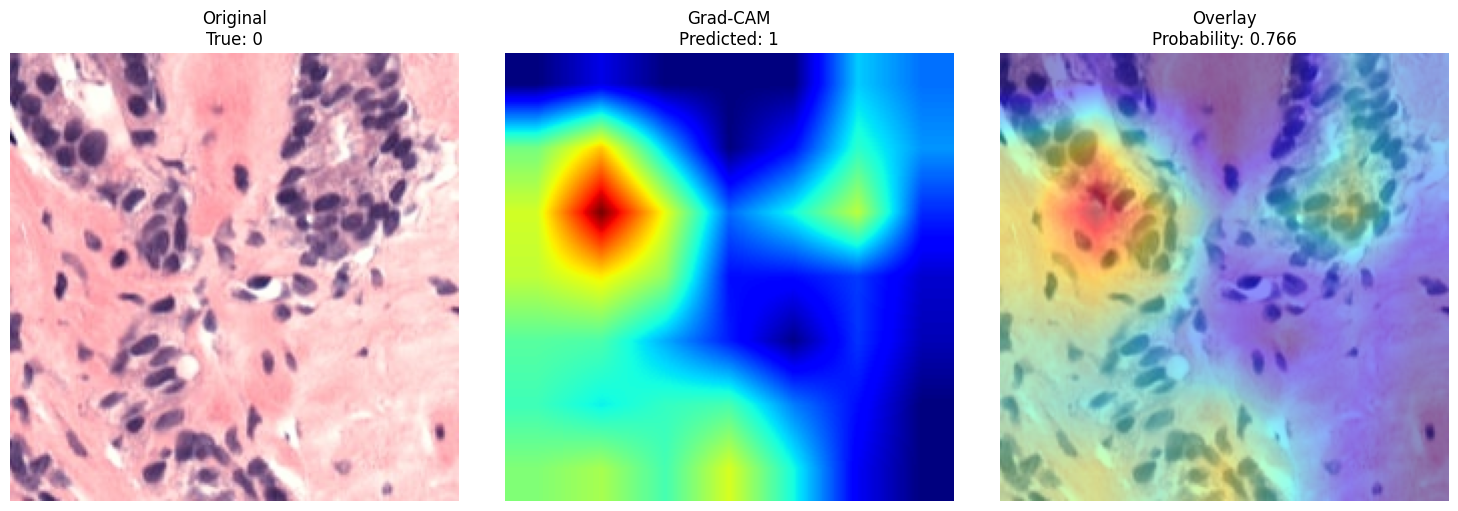

In [47]:
from PIL import Image

visual_image = image.resize((IMG_SIZE, IMG_SIZE))
visual_array = np.array(visual_image)

heatmap = plt.get_cmap("jet")(cam)[..., :3]

overlay = (
    0.55 * visual_array / 255.0
    + 0.45 * heatmap
)

overlay = np.clip(overlay, 0, 1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(visual_array)
plt.title(f"Original\nTrue: {sample_label}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet")
plt.title(f"Grad-CAM\nPredicted: {predicted_class}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(f"Overlay\nProbability: {predicted_probability:.3f}")
plt.axis("off")

plt.tight_layout()
plt.show()

In [48]:
gradcam_dir = WORK_DIR / "gradcam"
gradcam_dir.mkdir(parents=True, exist_ok=True)

gradcam_path = gradcam_dir / f"{sample_row['tile_id']}_gradcam.png"

plt.savefig(
    gradcam_path,
    dpi=200,
    bbox_inches="tight"
)

print("Grad-CAM visualization saved:")
print(gradcam_path)
print(f"File size: {gradcam_path.stat().st_size / 1024:.2f} KB")

Grad-CAM visualization saved:
/content/pathoscope_03/gradcam/71abdfb52804bed1259c90f7b414e178_x512_y1024_gradcam.png
File size: 7.37 KB


<Figure size 640x480 with 0 Axes>

Grad-CAM visualization saved correctly:
/content/pathoscope_03/gradcam/71abdfb52804bed1259c90f7b414e178_x512_y1024_gradcam.png
File size: 349.81 KB


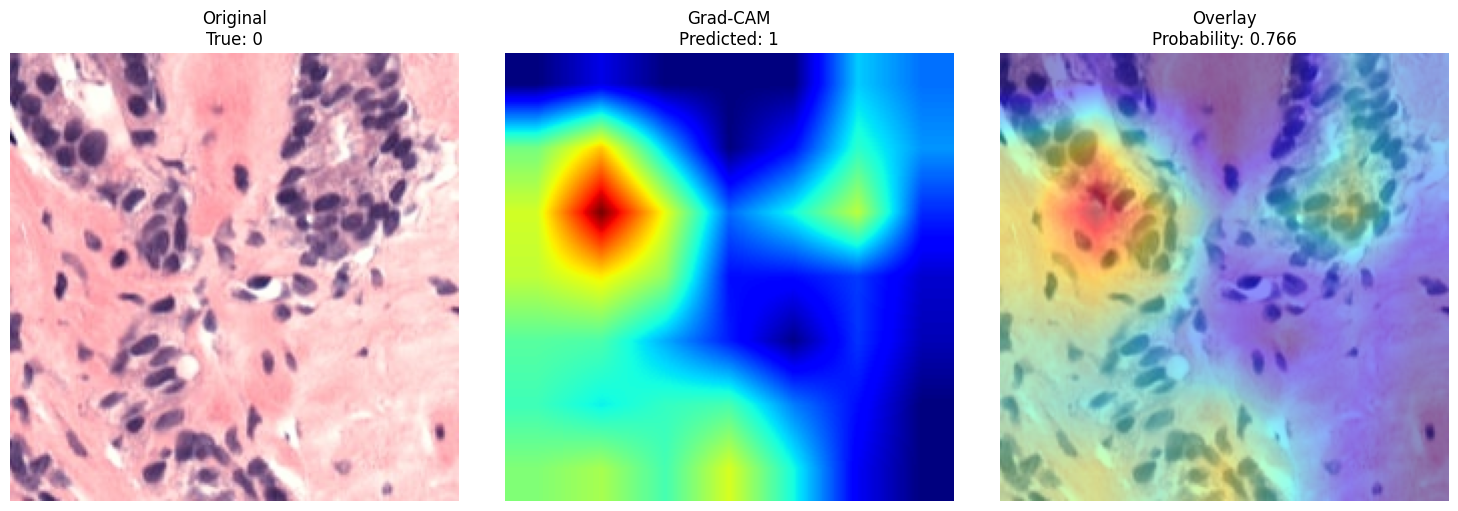

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(visual_array)
axes[0].set_title(f"Original\nTrue: {sample_label}")
axes[0].axis("off")

axes[1].imshow(cam, cmap="jet")
axes[1].set_title(f"Grad-CAM\nPredicted: {predicted_class}")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title(f"Overlay\nProbability: {predicted_probability:.3f}")
axes[2].axis("off")

fig.tight_layout()

gradcam_path = gradcam_dir / f"{sample_row['tile_id']}_gradcam.png"

fig.savefig(
    gradcam_path,
    dpi=200,
    bbox_inches="tight"
)

print("Grad-CAM visualization saved correctly:")
print(gradcam_path)
print(f"File size: {gradcam_path.stat().st_size / 1024:.2f} KB")

plt.show()
plt.close(fig)

In [50]:
import pandas as pd

model_comparison = pd.DataFrame([
    {
        "Model": "EfficientNet-B0",
        "Parameters": 4010110,
        "Validation_AUC": 0.8907,
        "Test_AUC": 0.7669,
        "Test_F1": 0.5866,
        "Test_Accuracy": 0.7709
    },
    {
        "Model": "ResNet50",
        "Parameters": 23512130,
        "Validation_AUC": 0.9081,
        "Test_AUC": 0.7941,
        "Test_F1": 0.6614,
        "Test_Accuracy": 0.7980
    },
    {
        "Model": "DenseNet121",
        "Parameters": 6955906,
        "Validation_AUC": 0.9097,
        "Test_AUC": 0.7841,
        "Test_F1": 0.6426,
        "Test_Accuracy": 0.8021
    }
])

comparison_path = WORK_DIR / "model_comparison.csv"

model_comparison.to_csv(comparison_path, index=False)

print("Model comparison")
print("================")
display(model_comparison)

print("\nSaved to:")
print(comparison_path)

Model comparison


,Model,Parameters,Validation_AUC,Test_AUC,Test_F1,Test_Accuracy
0,EfficientNet-B0,4010110,0.8907,0.7669,0.5866,0.7709
1,ResNet50,23512130,0.9081,0.7941,0.6614,0.7980
2,DenseNet121,6955906,0.9097,0.7841,0.6426,0.8021



Saved to:
/content/pathoscope_03/model_comparison.csv


In [51]:
OUTPUT_DRIVE = DATA_DIR / "notebook_03_results"
OUTPUT_DRIVE.mkdir(parents=True, exist_ok=True)

import shutil

files_to_save = [
    WORK_DIR / "tile_clf.pth",
    WORK_DIR / "tile_clf_densenet121.pth",
    WORK_DIR / "model_comparison.csv",
    gradcam_path
]

for source_file in files_to_save:
    destination_file = OUTPUT_DRIVE / source_file.name
    shutil.copy2(source_file, destination_file)
    print(f"Saved: {destination_file}")

print("\nNotebook 03 results folder:")
print(OUTPUT_DRIVE)

Saved: /content/drive/MyDrive/PathoScope/data/notebook_03_results/tile_clf.pth
Saved: /content/drive/MyDrive/PathoScope/data/notebook_03_results/tile_clf_densenet121.pth
Saved: /content/drive/MyDrive/PathoScope/data/notebook_03_results/model_comparison.csv
Saved: /content/drive/MyDrive/PathoScope/data/notebook_03_results/71abdfb52804bed1259c90f7b414e178_x512_y1024_gradcam.png

Notebook 03 results folder:
/content/drive/MyDrive/PathoScope/data/notebook_03_results
